# Regression & Its Evaluation

**1. What is Simple Linear Regression?**

 - Simple linear regression is a statistical method used to model the relationship between two continuous variables by fitting a straight line to the observed data. It aims to determine how changes in one variable, called the independent (or predictor) variable (x), affect another variable, known as the dependent (or response) variable (y).

**2. What are the key assumptions of Simple Linear Regression?**

 - Linearity, Independence of Observations (No Autocorrelation), Homoscedasticity (Constant Variance), No Significant Outliers, Normality of Residuals.

**3. What is heteroscedasticity, and why is it important to address in regression models?**

- Heteroscedasticity refers to a condition in regression analysis where the variance of the residuals (errors) is not constant across all levels of the independent variables. Instead of an even spread of data points around a regression line, the "scatter" changes systematically—often forming a distinctive cone or fan shape in residual plots.

 - **Why Addressing It Is Important**

   Standard Ordinary Least Squares (OLS) regression assumes constant error variance (homoscedasticity). Violating this assumption has several critical consequences.

   **Unreliable Hypothesis Testing:** Heteroscedasticity biases the calculation of standard errors. This renders p-values, t-tests, and F-tests unreliable, often leading to "false positives" (Type I errors) where a variable appears statistically significant when it is not.

   **Inefficient Estimates:** While the estimated coefficients remain unbiased, they are no longer the most precise (they are no longer "BLUE"—Best Linear Unbiased Estimator). They have higher variances, making them less stable and less likely to reflect true population values.

   **Misleading Predictions:** Models with heteroscedasticity produce forecasts with high variance and unreliable prediction intervals.

  **4. What is Multiple Linear Regression?**

  - Multiple Linear Regression (MLR) is a statistical technique used to model the linear relationship between one continuous dependent variable (target) and two or more independent variables (predictors).

  **5. What is polynomial regression, and how does it differ from linear
regression?**

 - Polynomial regression is a form of regression analysis that models the relationship between independent and dependent variables as an (n^th) degree polynomial. It is primarily used when data exhibits a curved or non-linear trend that a straight line cannot accurately represent.

 **6. Implement a Python program to fit a Simple Linear Regression model to
the following sample data:**

● X = [1, 2, 3, 4, 5]

● Y = [2.1, 4.3, 6.1, 7.9, 10.2]

**Plot the regression line over the data points.
(Include your Python code and output in the code box below.)**

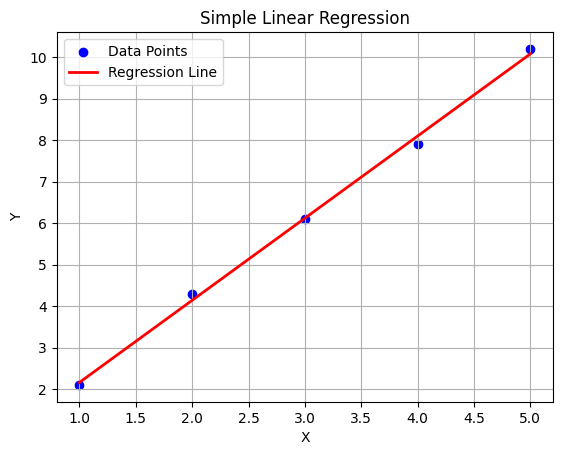

Slope (Coefficient): 1.98
Intercept: 0.18


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Sample data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)  # Reshape to 2D array for sklearn
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

# Initialize and fit the Simple Linear Regression model
model = LinearRegression()
model.fit(X, Y)

# Make predictions for the regression line
Y_pred = model.predict(X)

# Plotting the results
plt.scatter(X, Y, color='blue', label='Data Points')  # Original data
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')  # Fit line
plt.title('Simple Linear Regression')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# Displaying model parameters
print(f"Slope (Coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")


**7: Fit a Multiple Linear Regression model on this sample data:**

● Area = [1200, 1500, 1800, 2000]

● Rooms = [2, 3, 3, 4]

● Price = [250000, 300000, 320000, 370000]

**Check for multicollinearity using VIF and report the results.
(Include your Python code and output in the code box below.)**

In [ ]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Define Sample Data
data = {
    'Area': [1200, 1500, 1800, 2000],
    'Rooms': [2, 3, 3, 4],
    'Price': [250000, 300000, 320000, 370000]
}
df = pd.DataFrame(data)

# 2. Fit Multiple Linear Regression Model
X = df[['Area', 'Rooms']]
y = df['Price']
X_const = sm.add_constant(X) # Add intercept
model = sm.OLS(y, X_const).fit()

# 3. Calculate Variance Inflation Factor (VIF)
vif_df = pd.DataFrame()
vif_df["Variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Output Results
print("Model Coefficients:")
print(model.params)
print("\nVIF Results:")
print(vif_df)


Model Coefficients:
const    103157.894737
Area         63.157895
Rooms     34736.842105
dtype: float64

VIF Results:
  Variable         VIF
0     Area  127.796923
1    Rooms  127.796923


8.  Implement polynomial regression on the following data:

● X = [1, 2, 3, 4, 5]

● Y = [2.2, 4.8, 7.5, 11.2, 14.7]

Fit a 2nd-degree polynomial and plot the resulting curve.
(Include your Python code and output in the code box below.)


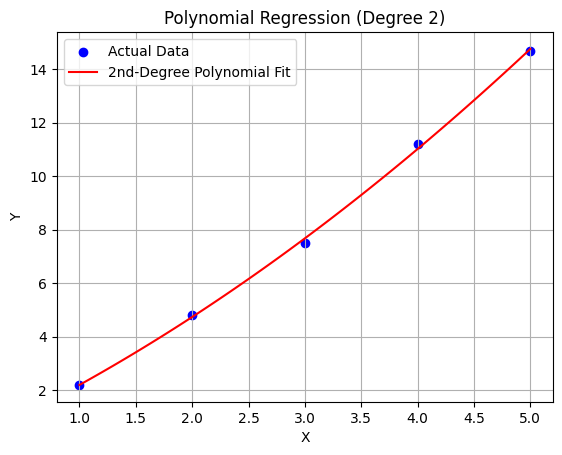

Intercept (beta_0): 0.06
Coefficients (beta_1, beta_2): [1.94 0.2 ]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. Define Sample Data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.2, 4.8, 7.5, 11.2, 14.7])

# 2. Transform Data for 2nd-degree Polynomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# 3. Fit Model
model = LinearRegression()
model.fit(X_poly, Y)

# 4. Generate curve for plotting
X_range = np.linspace(1, 5, 100).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
Y_range_pred = model.predict(X_range_poly)

# 5. Plotting
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X_range, Y_range_pred, color='red', label='2nd-Degree Polynomial Fit')
plt.title('Polynomial Regression (Degree 2)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# Output Results
print(f"Intercept (beta_0): {model.intercept_:.2f}")
print(f"Coefficients (beta_1, beta_2): {model.coef_}")


**9: Create a residuals plot for a regression model trained on this data:**

● X = [10, 20, 30, 40, 50]

● Y = [15, 35, 40, 50, 65]

**Assess heteroscedasticity by examining the spread of residuals.
(Include your Python code and output in the code box below.)**

- For the given data, the residuals (errors) show a random spread around the zero-line with no clear fan or cone shape, suggesting that the assumption of homoscedasticity is likely met and there is no significant heteroscedasticity.

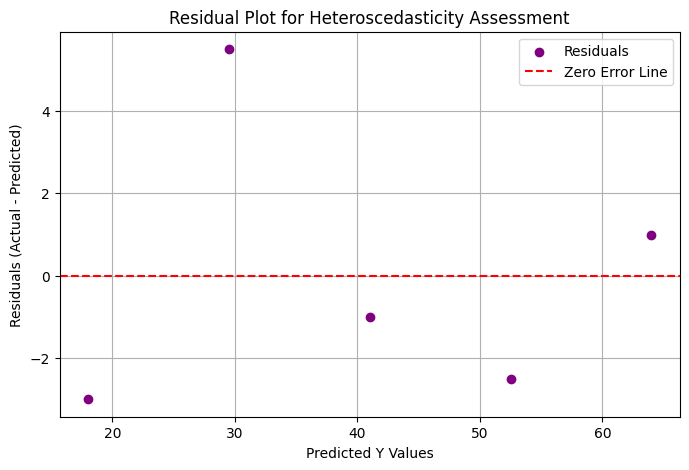

Predicted Values: [18.  29.5 41.  52.5 64. ]
Residuals: [-3.   5.5 -1.  -2.5  1. ]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Define Sample Data
X = np.array([10, 20, 30, 40, 50]).reshape(-1, 1)
Y = np.array([15, 35, 40, 50, 65])

# 2. Fit the Model and Calculate Residuals
model = LinearRegression().fit(X, Y)
Y_pred = model.predict(X)
residuals = Y - Y_pred

# 3. Create Residuals Plot
plt.figure(figsize=(8, 5))
plt.scatter(Y_pred, residuals, color='purple', label='Residuals')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Error Line')
plt.xlabel('Predicted Y Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Heteroscedasticity Assessment')
plt.legend()
plt.grid(True)
plt.show()

# Output individual residuals for inspection
print(f"Predicted Values: {Y_pred}")
print(f"Residuals: {residuals}")


 **10: Imagine you are a data scientist working for a real estate company. You
need to predict house prices using features like area, number of rooms, and location.**

However, you detect heteroscedasticity and multicollinearity in your regression model.

**Explain the steps you would take to address these issues and ensure a robust
model.**

 - As a data scientist predicting house prices, encountering heteroscedasticity and multicollinearity is common because property features like Area and Number of Rooms are naturally correlated and exhibit higher variance at higher price points.
To build a robust model, I would take the following steps:

**1. Address Multicollinearity**
Multicollinearity inflates the variance of coefficient estimates, making them unstable.

**Feature Selection & Engineering:** Use Variance Inflation Factor (VIF) to identify redundant features (typically VIF > 5 or 10). I would drop one of the highly correlated variables—for instance, keeping "area" but removing "number of rooms" if they overlap significantly.

**Dimensionality Reduction** Apply Principal Component Analysis (PCA) to transform correlated features into a smaller set of uncorrelated components.

**2. Address Heteroscedasticity**
Heteroscedasticity (non-constant error variance) makes standard errors and hypothesis tests unreliable.

**Logarithmic Transformations:** Apply a log transformation to the dependent variable (Price). In real estate, price is often log-normally distributed; transforming it stabilizes variance and often makes the relationship more linear.

**Weighted Least Squares (WLS):** Assign weights to observations based on the inverse of their variance. Data points with higher variance (e.g., extremely luxury homes) are given less weight to prevent them from disproportionately influencing the model.

**3. Ensure Model Robustness**

**Cross-Validation:** Use k-fold cross-validation to ensure the model isn't overfitting to specific clusters of data.

**Residual Analysis:** Plot residuals against fitted values to confirm that the "cone" pattern of heteroscedasticity has been eliminated.

**Outlier Detection:** Use metrics like Cook's Distance to identify and handle influential outliers that may exacerbate both issues.